In [2]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('mobile_dataset.csv')
# df.head(5)
# df.tail(5)
df.sample(10)

,brand,model_name,price_npr,ram_gb,storage_gb,screen_size_inches,battery_mah,camera_mp,processor,operating_system,5g_support,fast_charging,fingerprint_sensor,release_year,seller_location,condition,warranty_months
182,Samsung,Galaxy A54 5G,38999,8,128,6.50,5000,50,Exynos 1380,Android,True,True,True,2023,Kathmandu,Brand New,12
768,Huawei,Huawei Nova 9 SE,27999,8,256,6.57,4300,108,Kirin 985,Android,True,True,True,2021,Biratnagar,Like New,12
821,Xiaomi,Redmi Note 12 Pro,19999,6,128,6.60,5000,108,MediaTek Helio G96,Android,True,True,True,2022,Pokhara,Brand New,12
988,Huawei,P50 Pro,54999,8,256,6.60,4360,50,Kirin 9000L,Android,True,True,True,2023,Kathmandu,Like New,18
502,Samsung,Galaxy A54 5G,28999,8,128,6.50,5000,50,Exynos 1280,Android,True,True,True,2023,Kathmandu,Like New,12
698,Infinix,Infinix Zero Ultra,54999,12,256,6.80,4500,200,MediaTek Dimensity 920,Android,True,True,True,2023,Kathmandu,Brand New,24
730,Realme,C55,14999,4,64,6.56,5000,50,MediaTek Helio G88,Android,False,True,True,2022,Biratnagar,Good,6
630,Huawei,Nova Y70,24999,6,128,6.75,6000,50,Kirin-like,Android,True,False,True,2023,Biratnagar,Brand New,24
665,Nokia,G42 5G,17999,6,128,6.60,5000,50,Snapdragon 480+,Android,True,False,True,2022,Dharan,Like New,6
728,Oppo,A57 5G,19999,6,128,6.56,5000,48,Qualcomm Snapdragon 695,Android,True,True,True,2023,Pokhara,Like New,12


# Data Understanding

`check how big is our data`

In [4]:
print(f'{df.shape} = The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.')

(1008, 17) = The dataset contains 1008 rows and 17 columns.


## column data types, non null values, size

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   brand               1008 non-null   object 
 1   model_name          1008 non-null   object 
 2   price_npr           1008 non-null   int64  
 3   ram_gb              1008 non-null   int64  
 4   storage_gb          1008 non-null   int64  
 5   screen_size_inches  1008 non-null   float64
 6   battery_mah         1008 non-null   int64  
 7   camera_mp           1008 non-null   int64  
 8   processor           1008 non-null   object 
 9   operating_system    1008 non-null   object 
 10  5g_support          1008 non-null   bool   
 11  fast_charging       1008 non-null   bool   
 12  fingerprint_sensor  1008 non-null   bool   
 13  release_year        1008 non-null   int64  
 14  seller_location     1008 non-null   object 
 15  condition           1008 non-null   object 
 16  warran

In [6]:
df.isnull().sum().sort_values(ascending=False)

brand                 0
model_name            0
price_npr             0
ram_gb                0
storage_gb            0
screen_size_inches    0
battery_mah           0
camera_mp             0
processor             0
operating_system      0
5g_support            0
fast_charging         0
fingerprint_sensor    0
release_year          0
seller_location       0
condition             0
warranty_months       0
dtype: int64

In [7]:
print("the duplicates data count :", df.duplicated().sum())

the duplicates data count : 19


In [8]:
df[df.duplicated()]

,brand,model_name,price_npr,ram_gb,storage_gb,screen_size_inches,battery_mah,camera_mp,processor,operating_system,5g_support,fast_charging,fingerprint_sensor,release_year,seller_location,condition,warranty_months
541,Samsung,Galaxy A54 5G,34999,8,128,6.50,5000,50,Snapdragon 778G,Android,True,True,True,2023,Kathmandu,Like New,12
560,Samsung,Galaxy A54 5G,39999,8,128,6.50,5000,50,Exynos 1280,Android,True,True,True,2023,Kathmandu,Like New,12
634,Apple,iPhone 12,89999,4,128,6.10,2815,12,Apple A14,iOS,True,True,False,2020,Lalitpur,Like New,12
641,Samsung,Galaxy A54 5G,37999,8,128,6.50,5000,50,Exynos 1280,Android,True,True,True,2023,Kathmandu,Brand New,12
717,Samsung,Galaxy A54 5G,37999,8,128,6.50,5000,50,Exynos 1280,Android,True,True,True,2023,Kathmandu,Brand New,12
758,Samsung,Galaxy A54 5G,34999,8,128,6.50,5000,50,Exynos 1280,Android,True,True,True,2023,Kathmandu,Like New,12
883,Apple,iPhone SE (3rd Gen),79999,4,128,4.70,1821,12,Apple A15,iOS,True,True,False,2022,Kathmandu,Brand New,12
885,Samsung,Galaxy M14,14999,4,128,6.60,6000,50,Exynos 1330,Android,True,True,True,2023,Butwal,Brand New,24
919,Samsung,Galaxy A54 5G,39999,8,128,6.50,5000,50,Exynos 1280,Android,True,True,True,2023,Kathmandu,Like New,12
939,Samsung,Galaxy A54 5G,35999,8,128,6.50,5000,50,Snapdragon 778G,Android,True,True,True,2023,Kathmandu,Like New,12


In [9]:
df.drop_duplicates(inplace=True)

print("the duplicates data count after dropping duplicates:", df.duplicated().sum())

the duplicates data count after dropping duplicates: 0


In [10]:
df.describe()

,price_npr,ram_gb,storage_gb,screen_size_inches,battery_mah,camera_mp,release_year,warranty_months
count,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000
mean,36071.298281,6.541962,164.012133,6.477836,4695.822042,58.858443,2022.278059,12.100101
std,27045.680810,2.492399,88.754676,0.378612,846.003435,32.851096,0.927828,6.476608
min,7599.000000,2.000000,32.000000,4.700000,0.000000,8.000000,2019.000000,-12.000000
25%,17999.000000,4.000000,128.000000,6.440000,4500.000000,50.000000,2022.000000,9.000000
50%,25999.000000,6.000000,128.000000,6.570000,5000.000000,50.000000,2022.000000,12.000000
75%,39999.000000,8.000000,256.000000,6.670000,5000.000000,64.000000,2023.000000,12.000000
max,159999.000000,12.000000,512.000000,7.100000,7000.000000,200.000000,2024.000000,24.000000


In [11]:
df.describe(include='object')

,brand,model_name,processor,operating_system,seller_location,condition
count,989,989,989,989,989,989
unique,11,298,160,2,10,4
top,Samsung,Poco X5 Pro,Apple A15,Android,Kathmandu,Brand New
freq,180,36,64,890,287,311


In [12]:
df.corr(numeric_only=True)['price_npr'].sort_values(ascending=False)

price_npr             1.000000
storage_gb            0.431954
5g_support            0.351054
warranty_months       0.320182
fast_charging         0.294848
ram_gb                0.236319
release_year         -0.098549
fingerprint_sensor   -0.159443
camera_mp            -0.205470
screen_size_inches   -0.389670
battery_mah          -0.615552
Name: price_npr, dtype: float64

# 📊 Correlation Analysis with Price

## 🔼 Positively Correlated Features

Features that **increase** the price as they increase:

| Feature | Correlation | Impact |
|---------|-------------|--------|
| **storage_gb** | +0.41 | 📦 More storage → higher price (moderate impact) |
| **5g_support** | +0.35 | 📡 5G phones are generally more expensive |
| **warranty_months** | +0.31 | 🛡️ Longer warranty → slightly higher price |
| **fast_charging** | +0.28 | ⚡ Fast charging adds value |
| **ram_gb** | +0.22 | 💾 More RAM → higher price (weaker than storage) |

### 💡 Key Insight
**Storage** is the strongest positive predictor of price, followed by 5G connectivity and warranty coverage.

---

## 🔽 Negatively Correlated Features

Features showing an **inverse** relationship with price:

| Feature | Correlation | Insight |
|---------|-------------|---------|
| **battery_mah** | -0.62 | 🔋 Larger battery → **lower** price (budget phones prioritize battery life) |
| **screen_size_in** | -0.42 | 📱 Larger screen → **lower** price (budget phones often have large screens) |
| **camera_mp** | -0.24 | 📷 Higher MP ≠ higher price (MP is marketing; quality matters more) |
| **fingerprint_sensor** | -0.18 | 👆 Very common in budget phones |
| **release_year** | -0.10 | 📅 Newer year → lower price (the phone becomes old) |

### 💡 Key Insight
**Battery capacity** has the strongest negative correlation (-0.62) - budget manufacturers compensate for lower-end specs with larger batteries as a key selling point.

---

## 🎯 Summary
- **Top Price Driver**: Storage capacity (+0.41)
- **Biggest Surprise**: Battery capacity most negatively correlates (-0.62), followed by screen size (-0.42)
- **Marketing vs Reality**: Camera megapixels don't predict price well

# EDA

## 📊 Univariate Analysis

In univariate analysis, we take one feature (or column) and perform analysis on that feature independently.

### 📂 Data Types

We work with two main types of data:

#### 1️⃣ Categorical Data
Used for variables that represent categories or groups.

##### ✅ Examples
- `Gender` → `Male`, `Female`
- `City` → `Kathmandu`, `Pokhara`, `Lalitpur`
- `Loan_Status` → `Approved`, `Rejected`

**Visualization Methods:**
- 📊 **Bar Chart** - Compare frequencies across categories
- 🥧 **Pie Chart** - Show proportions of a whole
- 🍩 **Donut Chart** - Pie chart variant with better readability

#### 2️⃣ Numerical Data
Used for variables that represent measurable quantities.

#### ✅ Examples
- `Age` → `18`, `25`, `60`
- `Salary` → `45000`, `85000`
- `House_Price` → `5_000_000`, `12_000_000`

**Visualization Methods:**
- 📈 **Histogram (histplot)** - Display distribution of continuous data
- 📉 - **KDE Plot (kdeplot)** – Shows the data distribution along with the probability density curve
- 📦 **Box Plot** - Identify outliers and quartiles
- 📐 **Q-Q Plot** - Check if data follows normal distribution
- 🎻 **Violin Plot** – Combines a box plot with a probability density curve

### Univariate Analysis for Categorical Data

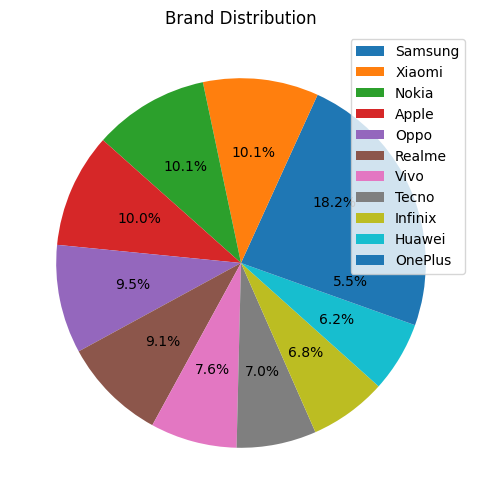

In [13]:
df['brand'].value_counts().plot(
    kind='pie',
    figsize=(8, 6),
    title='Brand Distribution',
    autopct='%1.1f%%',
    legend=True,
    labels=None
)
plt.ylabel('')
plt.show()


# autopct='%1.0f%%'   # 23%
# autopct='%1.1f%%'   # 23.5%
# autopct='%1.2f%%'   # 23.46%

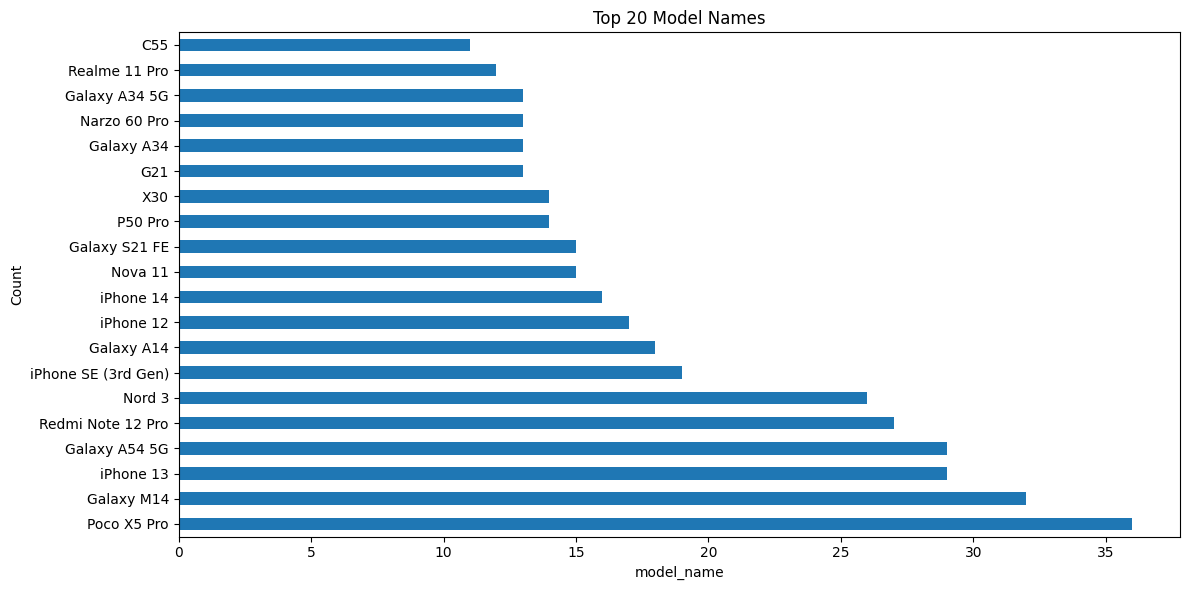

In [14]:
df['model_name'].value_counts().head(20).plot(kind='barh', figsize=(12,6), title='Top 20 Model Names') 
plt.xlabel('model_name')
plt.tight_layout()
plt.ylabel('Count')
plt.show()

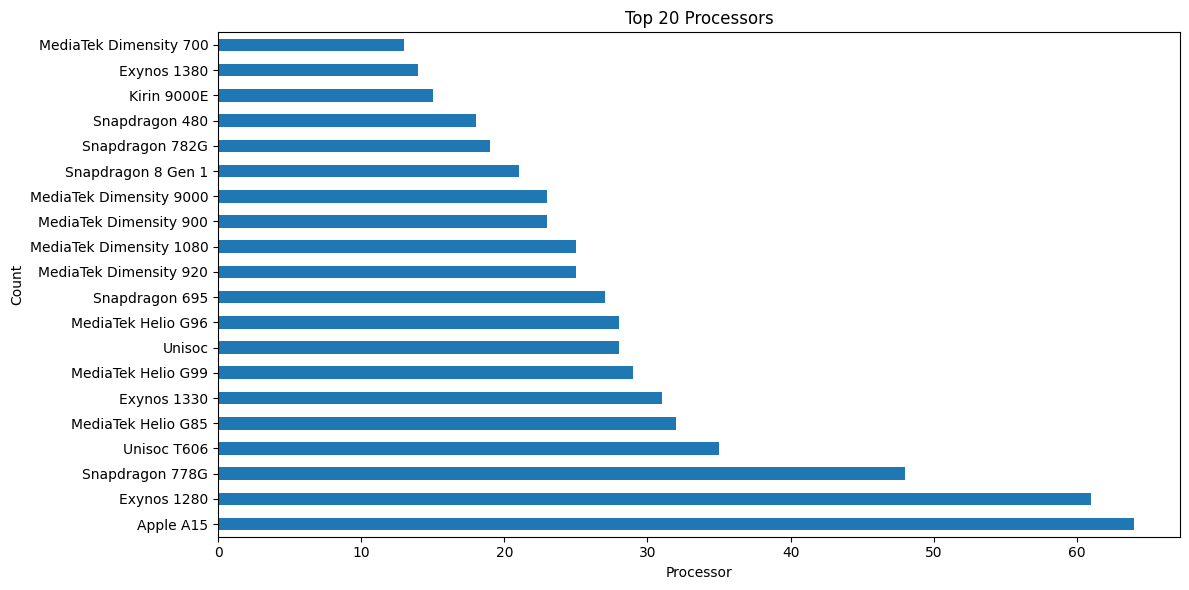

In [15]:
df['processor'].value_counts().head(20).plot(kind='barh', figsize=(12,6), title='Top 20 Processors') 
plt.xlabel('Processor')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

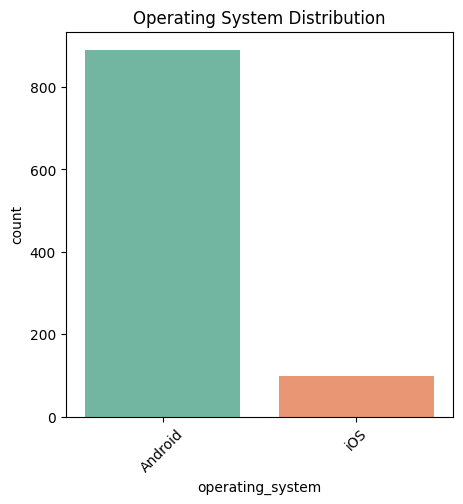

In [16]:

plt.figure(figsize=(5, 5))
sns.countplot(
    data=df,
    x='operating_system',
    hue='operating_system',
    order=df['operating_system'].value_counts().index,
    palette='Set2',
    legend=False
)

plt.xticks(rotation=45)
plt.title("Operating System Distribution")
plt.show()


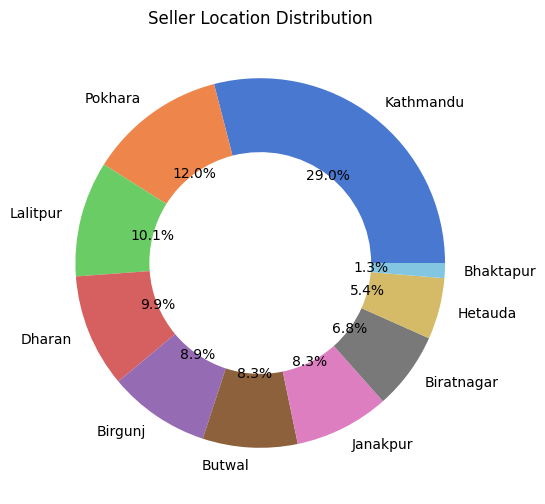

In [17]:
# Data
seller_locations = df['seller_location'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    seller_locations,
    labels=seller_locations.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("muted", n_colors=df['seller_location'].nunique()),
    wedgeprops={'width': 0.4}  # donut effect
)

plt.title("Seller Location Distribution")
plt.show()


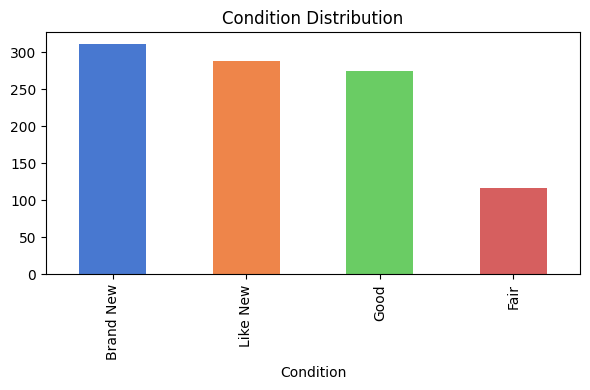

In [18]:
df['condition'].value_counts().plot(
    kind='bar',
    color=sns.color_palette("muted", n_colors=df['condition'].nunique()),
    figsize=(6, 4),
    title='Condition Distribution',
)
plt.xlabel('Condition')
plt.tight_layout()
plt.show()

### Univariate Analysis for Numerical Data

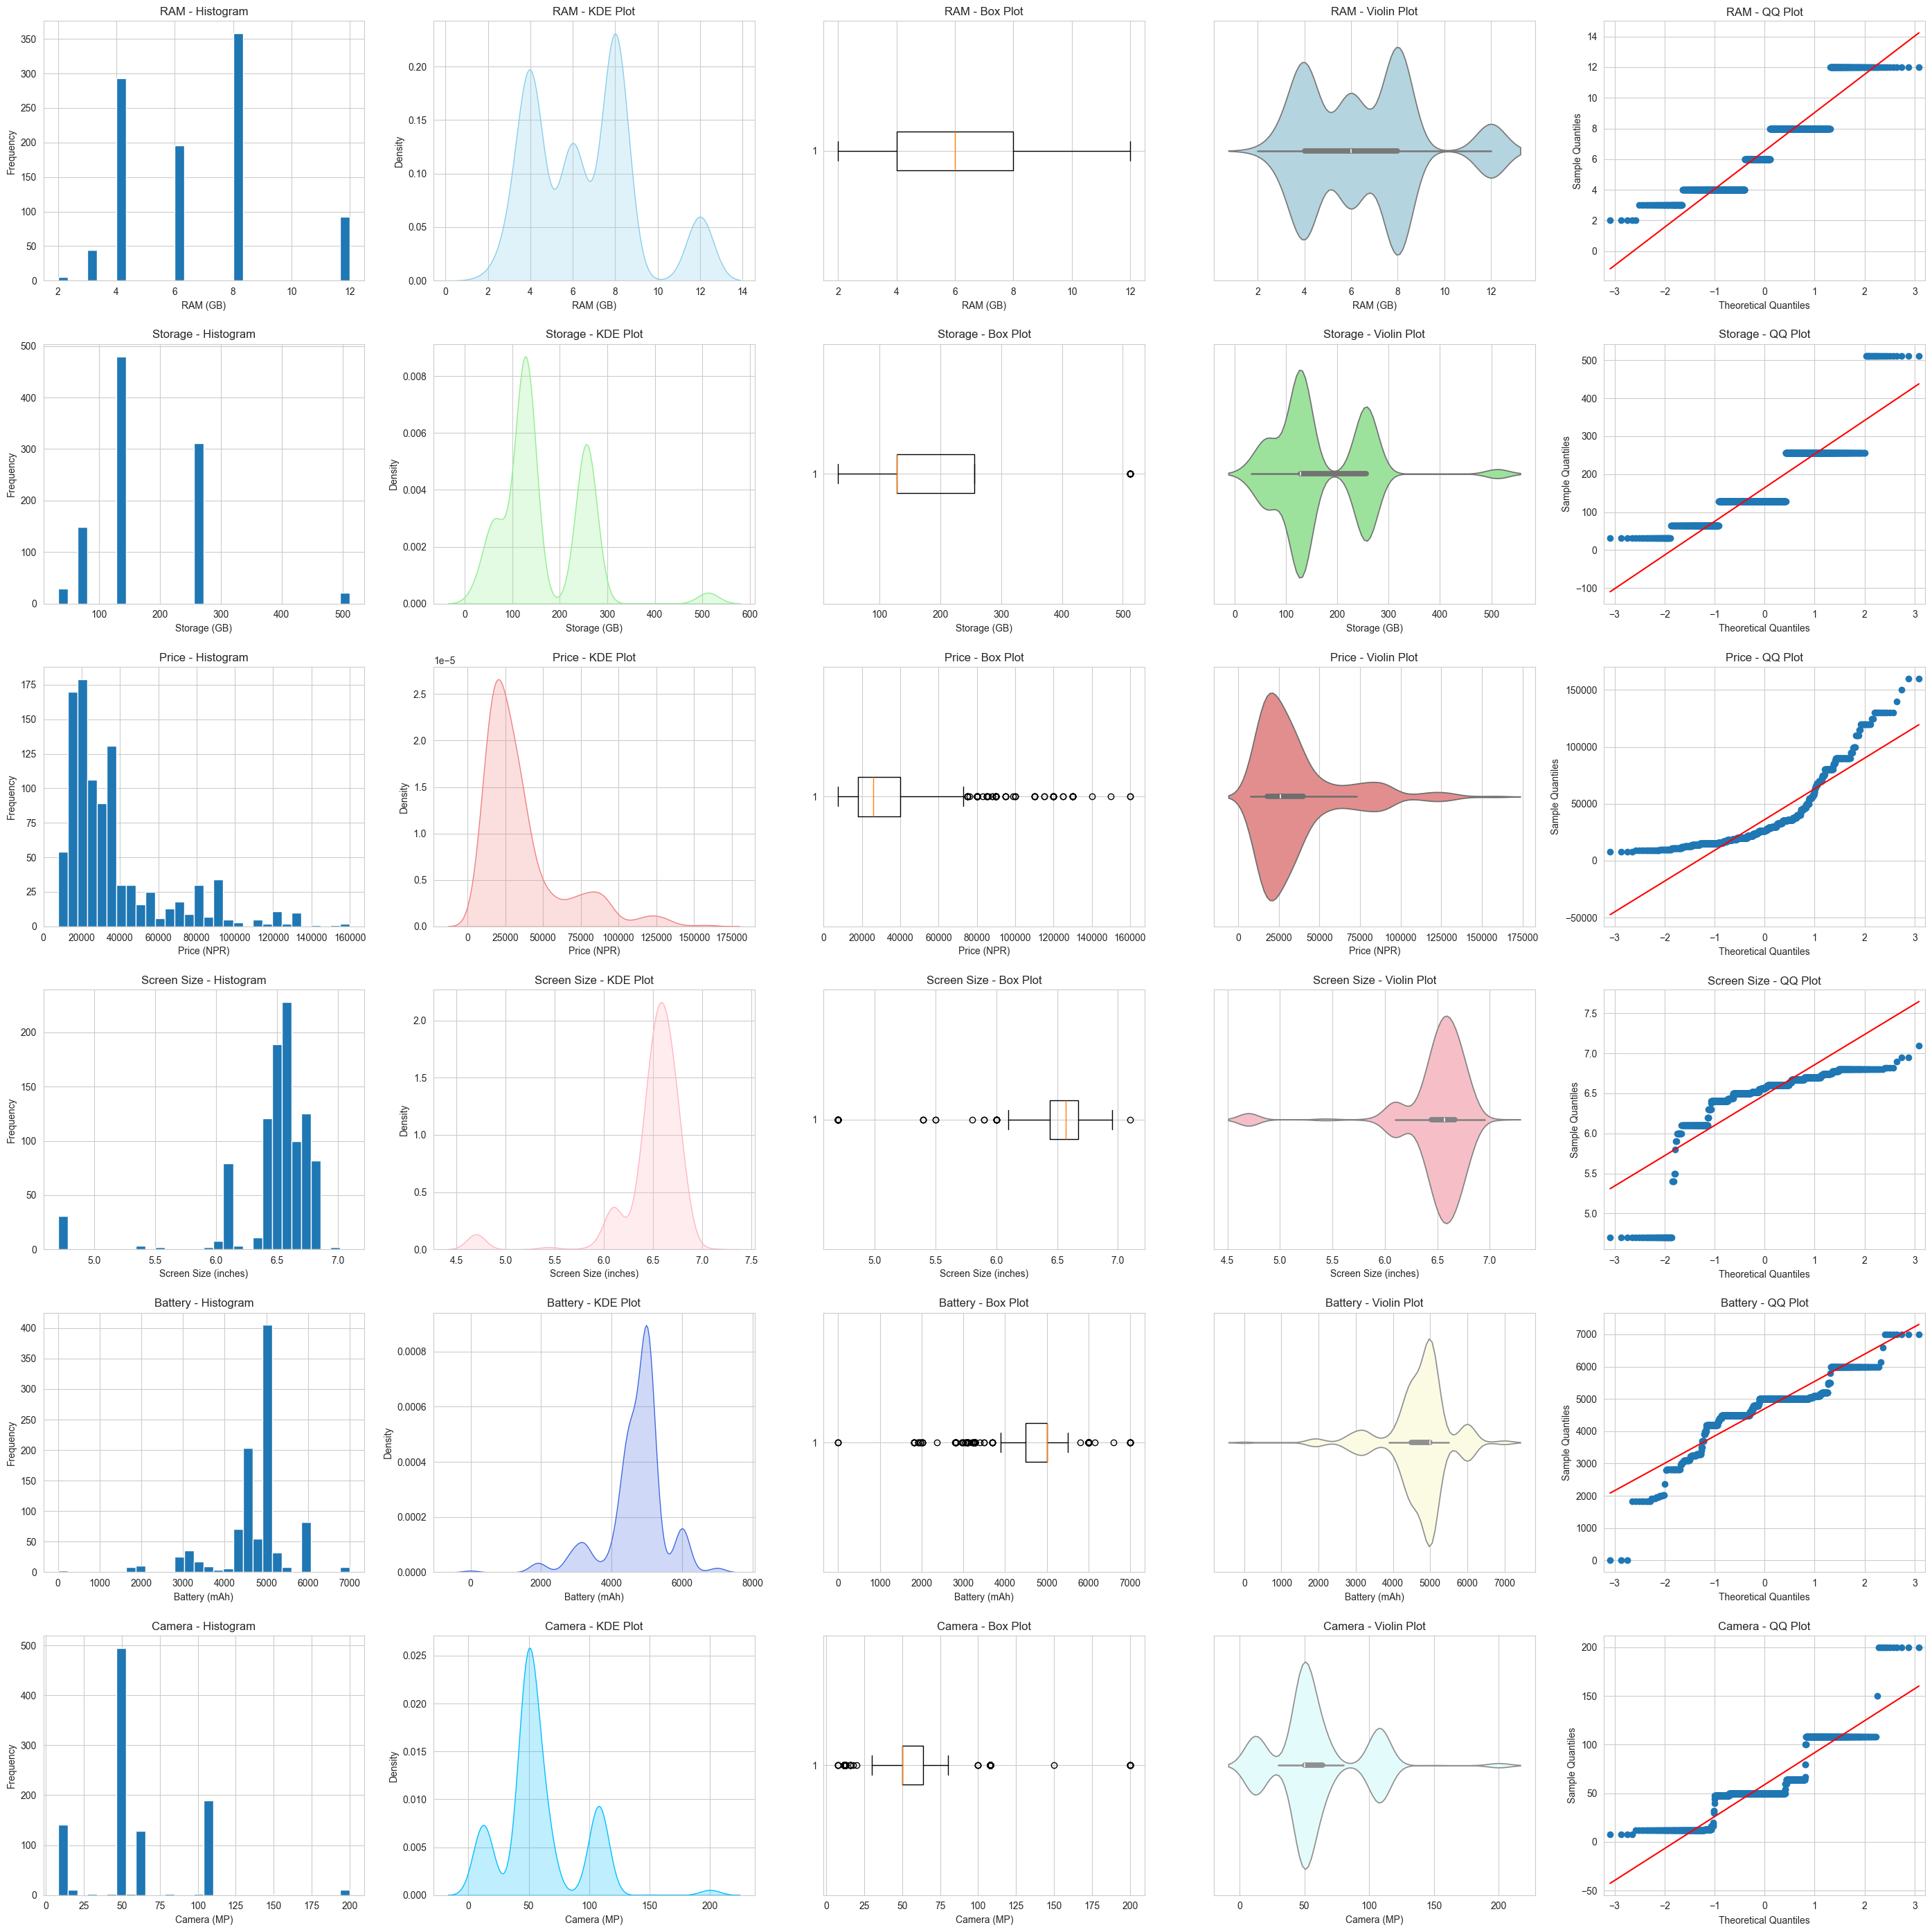

In [19]:
sns.set_style("whitegrid")

ram_gb = df["ram_gb"]
storage_gb = df["storage_gb"]
price_npr = df["price_npr"]
screen_size_inches = df['screen_size_inches']
battery_mah = df['battery_mah']
camera_mp = df['camera_mp']

fig, ax = plt.subplots(nrows=6, ncols=5, figsize=(28, 28))
ax = ax.flatten()

# ---------- RAM ----------
ax[0].hist(ram_gb.dropna(), bins=30)
ax[0].set_title("RAM - Histogram")
ax[0].set_xlabel("RAM (GB)")
ax[0].set_ylabel("Frequency")

sns.kdeplot(ram_gb.dropna(), fill=True, ax=ax[1], color="skyblue")
ax[1].set_title("RAM - KDE Plot")
ax[1].set_xlabel("RAM (GB)")
ax[1].set_ylabel("Density")

ax[2].boxplot(ram_gb.dropna(), vert=False)
ax[2].set_title("RAM - Box Plot")
ax[2].set_xlabel("RAM (GB)")

sns.violinplot(x=ram_gb.dropna(), ax=ax[3], color="lightblue")
ax[3].set_title("RAM - Violin Plot")
ax[3].set_xlabel("RAM (GB)")

sm.qqplot(ram_gb.dropna(), line='s', ax=ax[4])
ax[4].set_title("RAM - QQ Plot")
ax[4].set_xlabel("Theoretical Quantiles")
ax[4].set_ylabel("Sample Quantiles")

# ---------- Storage ----------
ax[5].hist(storage_gb.dropna(), bins=30)
ax[5].set_title("Storage - Histogram")
ax[5].set_xlabel("Storage (GB)")
ax[5].set_ylabel("Frequency")

sns.kdeplot(storage_gb.dropna(), fill=True, ax=ax[6], color="lightgreen")
ax[6].set_title("Storage - KDE Plot")
ax[6].set_xlabel("Storage (GB)")
ax[6].set_ylabel("Density")

ax[7].boxplot(storage_gb.dropna(), vert=False)
ax[7].set_title("Storage - Box Plot")
ax[7].set_xlabel("Storage (GB)")

sns.violinplot(x=storage_gb.dropna(), ax=ax[8], color="lightgreen")
ax[8].set_title("Storage - Violin Plot")
ax[8].set_xlabel("Storage (GB)")

sm.qqplot(storage_gb.dropna(), line='s', ax=ax[9])
ax[9].set_title("Storage - QQ Plot")
ax[9].set_xlabel("Theoretical Quantiles")
ax[9].set_ylabel("Sample Quantiles")

# ---------- Price ----------
ax[10].hist(price_npr.dropna(), bins=30)
ax[10].set_title("Price - Histogram")
ax[10].set_xlabel("Price (NPR)")
ax[10].set_ylabel("Frequency")

sns.kdeplot(price_npr.dropna(), fill=True, ax=ax[11], color="lightcoral")
ax[11].set_title("Price - KDE Plot")
ax[11].set_xlabel("Price (NPR)")
ax[11].set_ylabel("Density")

ax[12].boxplot(price_npr.dropna(), vert=False)
ax[12].set_title("Price - Box Plot")
ax[12].set_xlabel("Price (NPR)")

sns.violinplot(x=price_npr.dropna(), ax=ax[13], color="lightcoral")
ax[13].set_title("Price - Violin Plot")
ax[13].set_xlabel("Price (NPR)")

sm.qqplot(price_npr.dropna(), line='s', ax=ax[14])
ax[14].set_title("Price - QQ Plot")
ax[14].set_xlabel("Theoretical Quantiles")
ax[14].set_ylabel("Sample Quantiles")

# ---------- Screen Size ----------
ax[15].hist(screen_size_inches.dropna(), bins=30)
ax[15].set_title("Screen Size - Histogram")
ax[15].set_xlabel("Screen Size (inches)")
ax[15].set_ylabel("Frequency")

sns.kdeplot(screen_size_inches.dropna(), fill=True, ax=ax[16], color="lightpink")
ax[16].set_title("Screen Size - KDE Plot")
ax[16].set_xlabel("Screen Size (inches)")
ax[16].set_ylabel("Density")

ax[17].boxplot(screen_size_inches.dropna(), vert=False)
ax[17].set_title("Screen Size - Box Plot")
ax[17].set_xlabel("Screen Size (inches)")

sns.violinplot(x=screen_size_inches.dropna(), ax=ax[18], color="lightpink")
ax[18].set_title("Screen Size - Violin Plot")
ax[18].set_xlabel("Screen Size (inches)")

sm.qqplot(screen_size_inches.dropna(), line='s', ax=ax[19])
ax[19].set_title("Screen Size - QQ Plot")
ax[19].set_xlabel("Theoretical Quantiles")
ax[19].set_ylabel("Sample Quantiles")

# ---------- Battery ----------
ax[20].hist(battery_mah.dropna(), bins=30)
ax[20].set_title("Battery - Histogram")
ax[20].set_xlabel("Battery (mAh)")
ax[20].set_ylabel("Frequency")

sns.kdeplot(battery_mah.dropna(), fill=True, ax=ax[21], color="royalblue") 
ax[21].set_title("Battery - KDE Plot")
ax[21].set_xlabel("Battery (mAh)")
ax[21].set_ylabel("Density")

ax[22].boxplot(battery_mah.dropna(), vert=False)
ax[22].set_title("Battery - Box Plot")
ax[22].set_xlabel("Battery (mAh)")

sns.violinplot(x=battery_mah.dropna(), ax=ax[23], color="lightyellow")
ax[23].set_title("Battery - Violin Plot")
ax[23].set_xlabel("Battery (mAh)")

sm.qqplot(battery_mah.dropna(), line='s', ax=ax[24])
ax[24].set_title("Battery - QQ Plot")
ax[24].set_xlabel("Theoretical Quantiles")
ax[24].set_ylabel("Sample Quantiles")

# ---------- Camera ----------
ax[25].hist(camera_mp.dropna(), bins=30)
ax[25].set_title("Camera - Histogram")
ax[25].set_xlabel("Camera (MP)")
ax[25].set_ylabel("Frequency")

sns.kdeplot(camera_mp.dropna(), fill=True, ax=ax[26], color="deepskyblue")  
ax[26].set_title("Camera - KDE Plot")
ax[26].set_xlabel("Camera (MP)")
ax[26].set_ylabel("Density")

ax[27].boxplot(camera_mp.dropna(), vert=False)
ax[27].set_title("Camera - Box Plot")
ax[27].set_xlabel("Camera (MP)")

sns.violinplot(x=camera_mp.dropna(), ax=ax[28], color="lightcyan")
ax[28].set_title("Camera - Violin Plot")
ax[28].set_xlabel("Camera (MP)")

sm.qqplot(camera_mp.dropna(), line='s', ax=ax[29])
ax[29].set_title("Camera - QQ Plot")
ax[29].set_xlabel("Theoretical Quantiles")
ax[29].set_ylabel("Sample Quantiles")

plt.tight_layout(h_pad=2.0)
plt.show()


## 📊 Bi- and Multivariate Analysis

In **bi- and multivariate analysis**, we study the relationships between **two or more features** in a dataset.

---

### 1️⃣ Numerical – Numerical
- **Scatter Plot** – Shows the relationship between two numerical variables.  
- **Line Plot** – Useful for visualizing trends over continuous values (e.g., time series).  
- **Pair Plot** – Displays pairwise relationships among multiple numerical features.

### 2️⃣ Numerical – Categorical
- **Bar Plot** – Compares numerical values across categories.  
- **Box Plot** – Highlights the distribution, median, and outliers for each category.  
- **KDE Plot** – Shows the density distribution of a numerical variable grouped by categories.

### 3️⃣ Categorical – Categorical
- **Heat Map** – Displays relationships (frequency or correlation) between categorical variables.  



### (Numerical - Numerical) : Feature Analysis

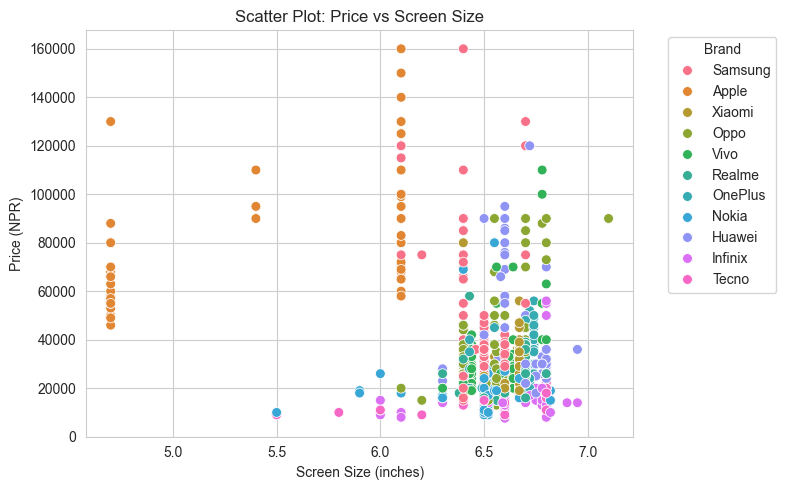

In [20]:

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='screen_size_inches', y='price_npr', hue='brand', s=50)

plt.title("Scatter Plot: Price vs Screen Size")
plt.ylabel("Price (NPR)")
plt.xlabel("Screen Size (inches)")

# Move legend to the right outside the plot
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()  # adjust layout to fit legend
plt.show()


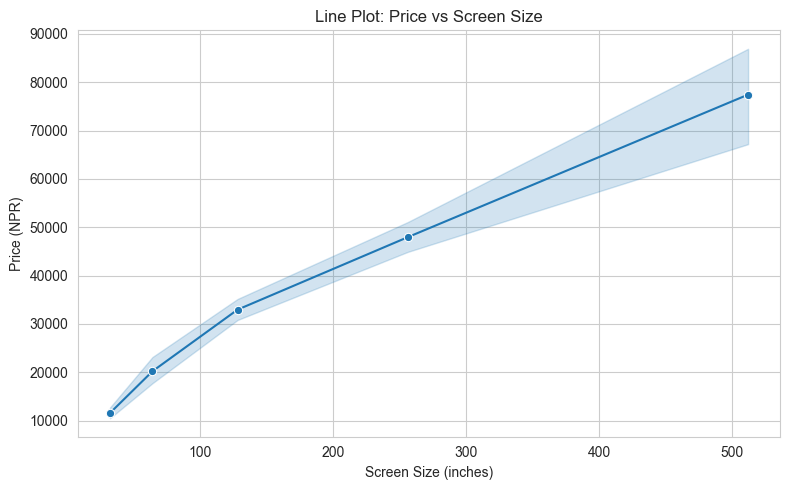

In [21]:

plt.figure(figsize=(8,5))

# Line plot
sns.lineplot(data=df, x='storage_gb', y='price_npr', marker='o')

plt.title("Line Plot: Price vs Screen Size")
plt.xlabel("Screen Size (inches)")
plt.ylabel("Price (NPR)")

plt.tight_layout()
plt.show()


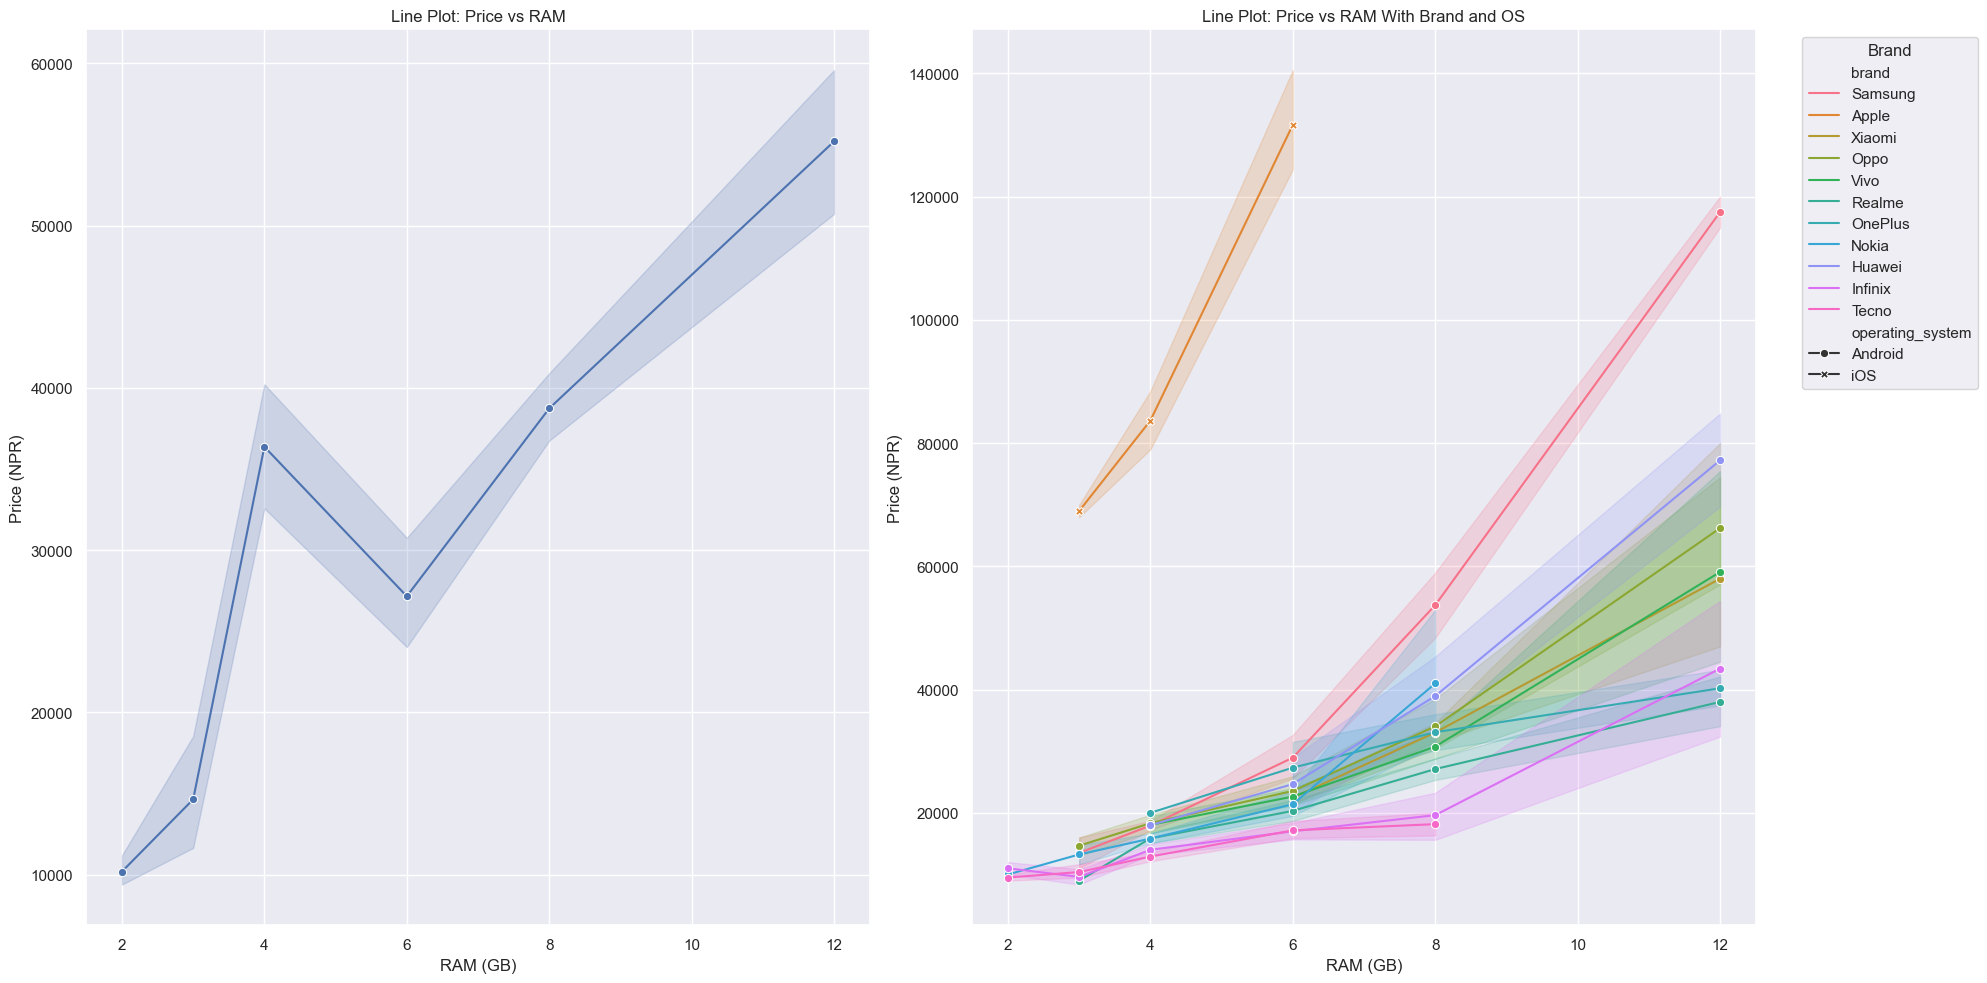

In [22]:
sns.set_theme(style="darkgrid") 
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
ax = ax.flatten()

sns.lineplot(data=df, x='ram_gb', y='price_npr', marker='o', ax=ax[0])
ax[0].set_title("Line Plot: Price vs RAM")
ax[0].set_xlabel("RAM (GB)")
ax[0].set_ylabel("Price (NPR)")

sns.lineplot(data=df, x='ram_gb', y='price_npr', hue='brand', style='operating_system', markers=True, dashes=False, ax=ax[1])
ax[1].set_title("Line Plot: Price vs RAM With Brand and OS")
ax[1].set_xlabel("RAM (GB)")
ax[1].set_ylabel("Price (NPR)")
ax[1].legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')



plt.tight_layout()
plt.show()


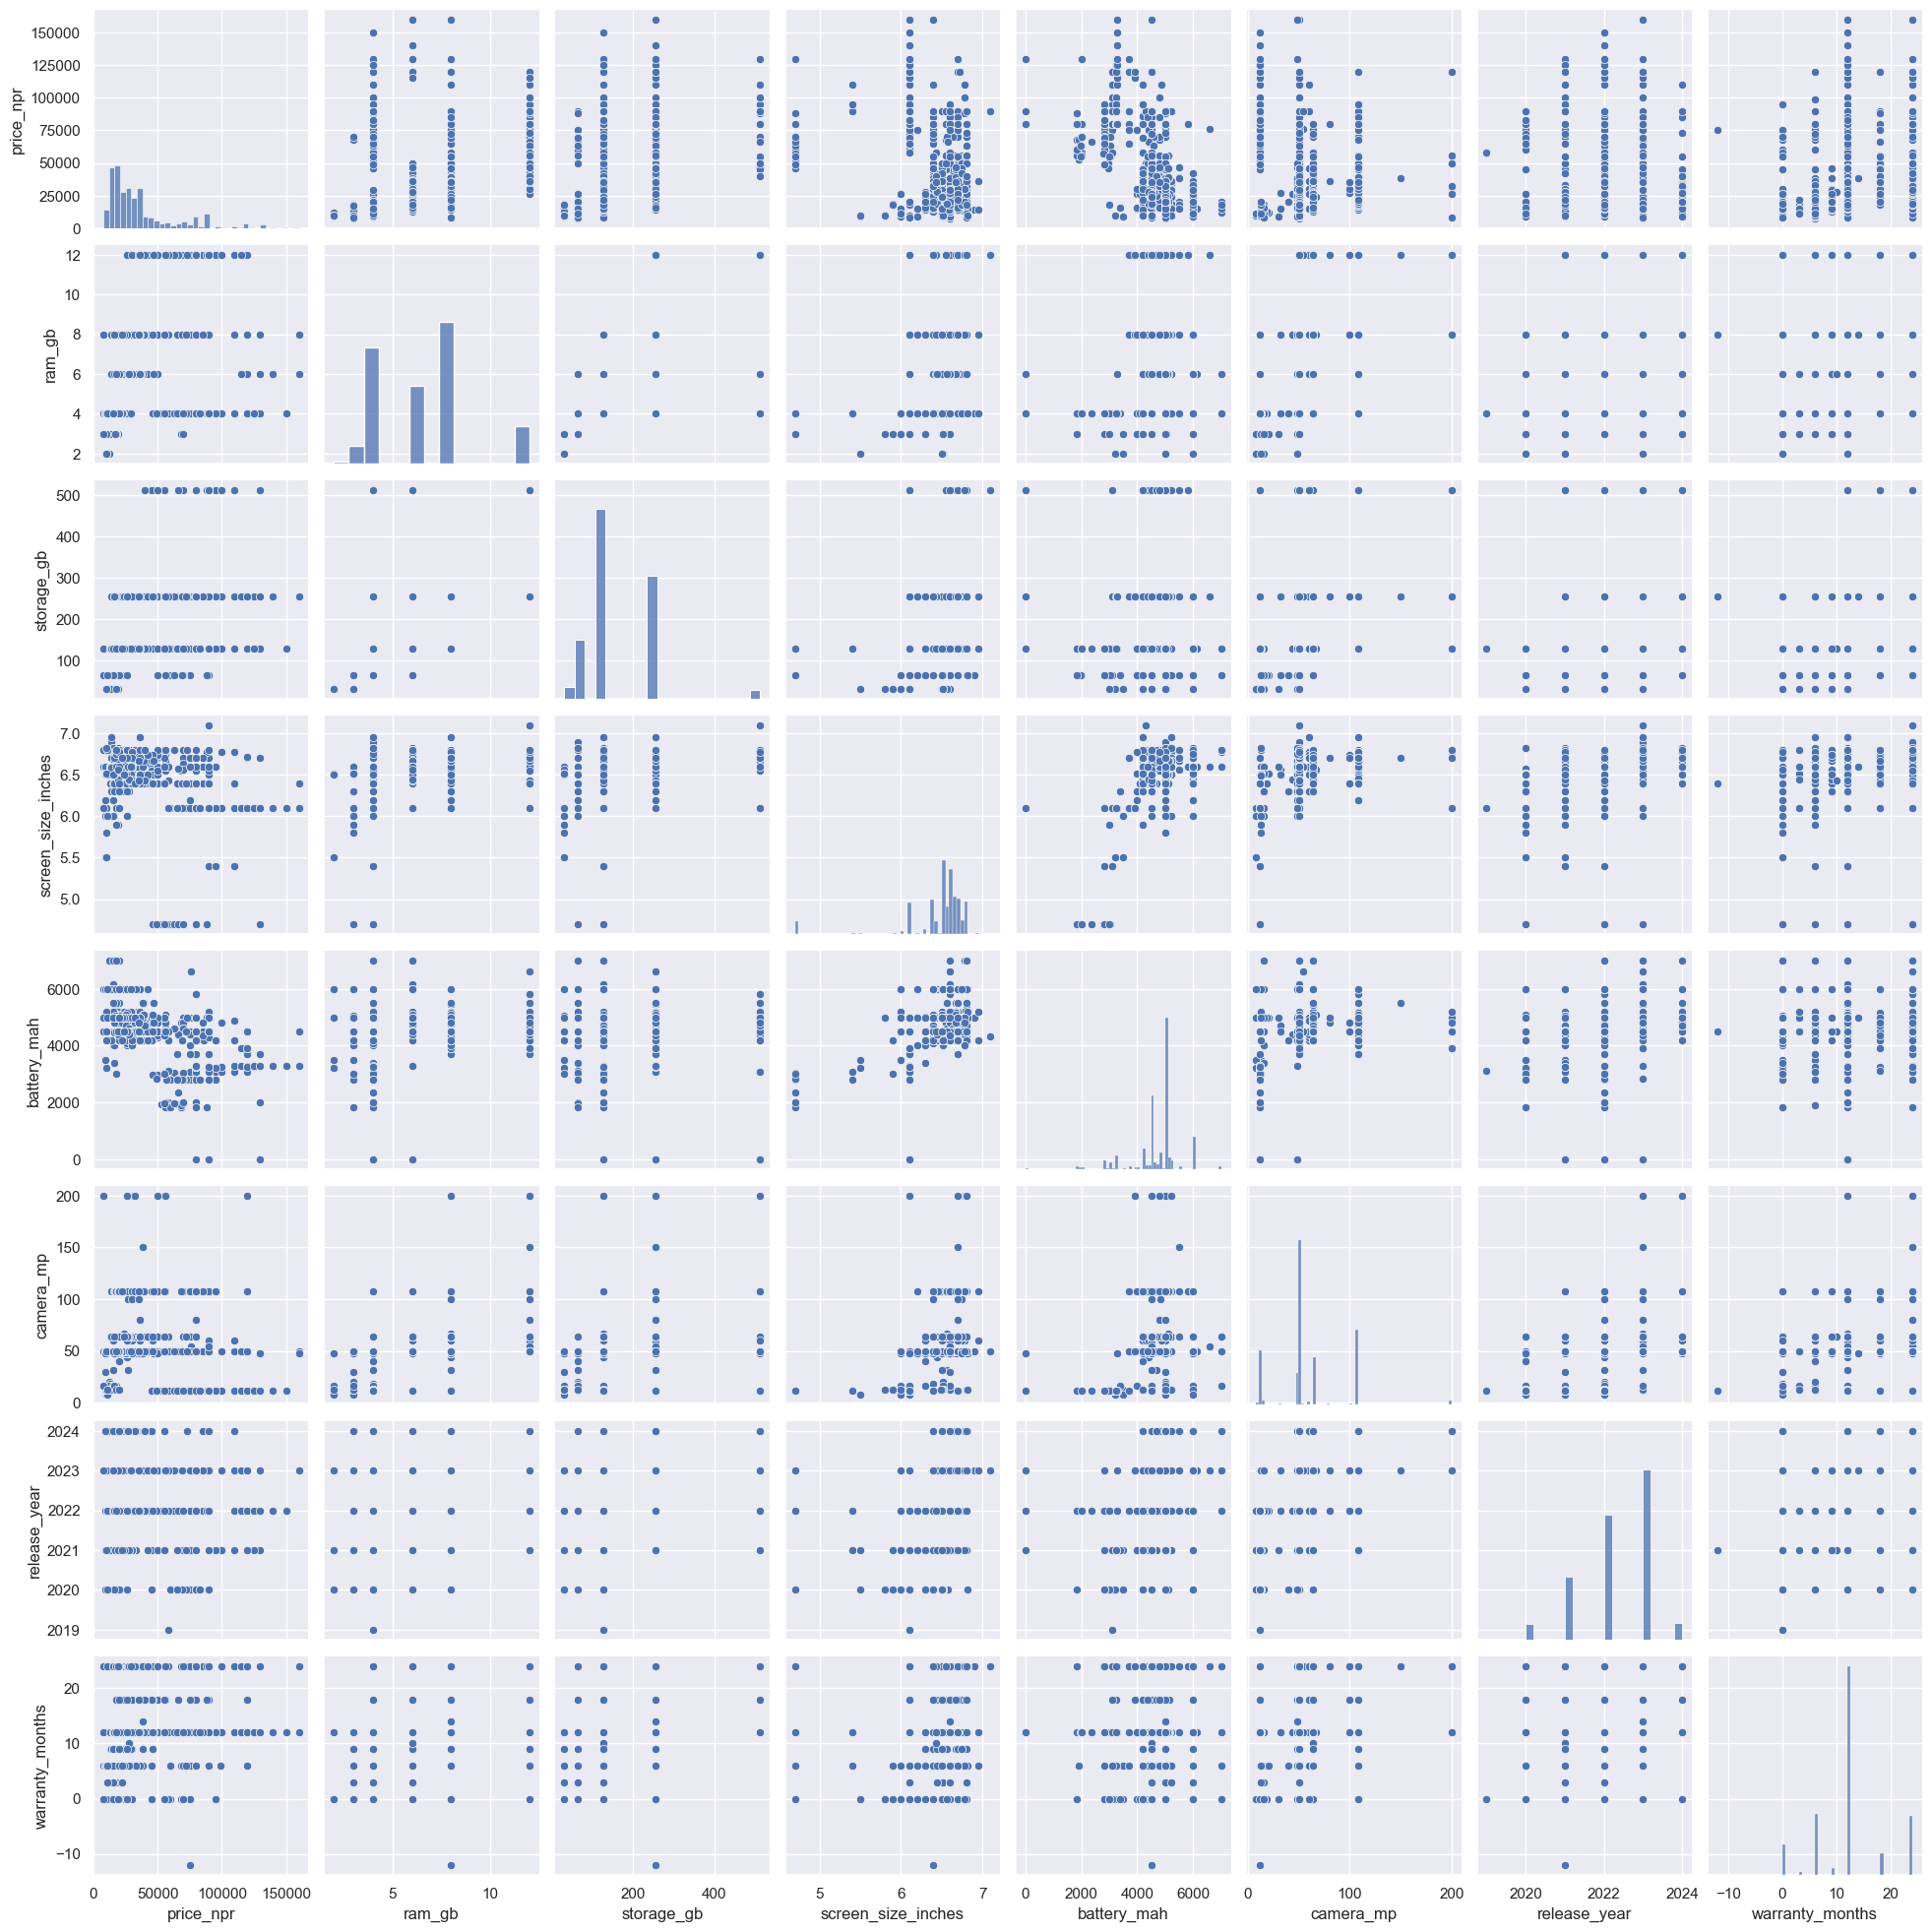

In [23]:
numeric_df = df.select_dtypes(include='number') 
sns.pairplot(numeric_df)
plt.show()

### (Numerical - Categorical) : Feature Analysis

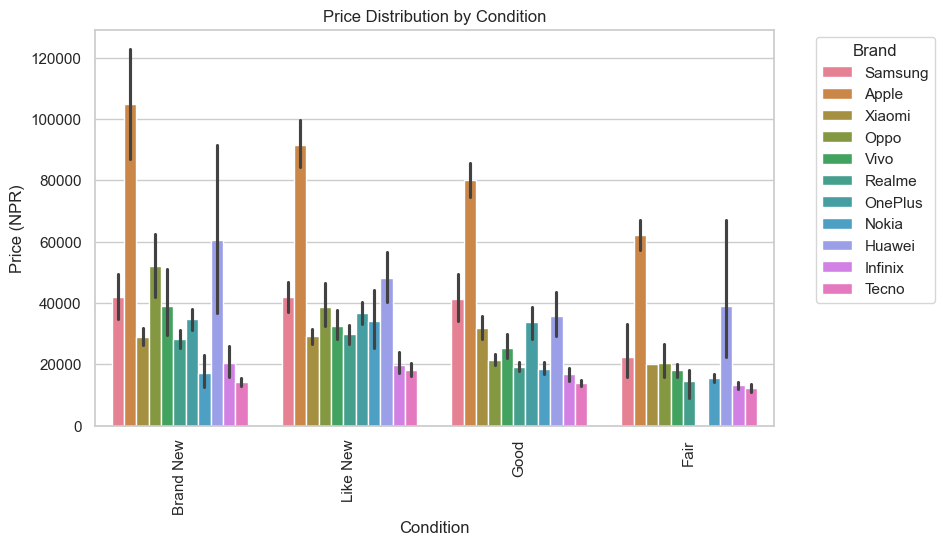

In [24]:
sns.set_theme(style="whitegrid")  
plt.figure(figsize=(8,5))

sns.barplot(data=df, x='condition', y='price_npr', hue='brand')  # numerical = price, categorical = condition

plt.title("Price Distribution by Condition")
plt.xlabel("Condition")
plt.ylabel("Price (NPR)")
plt.tight_layout()
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tick_params(axis='x', rotation=90)
plt.show()


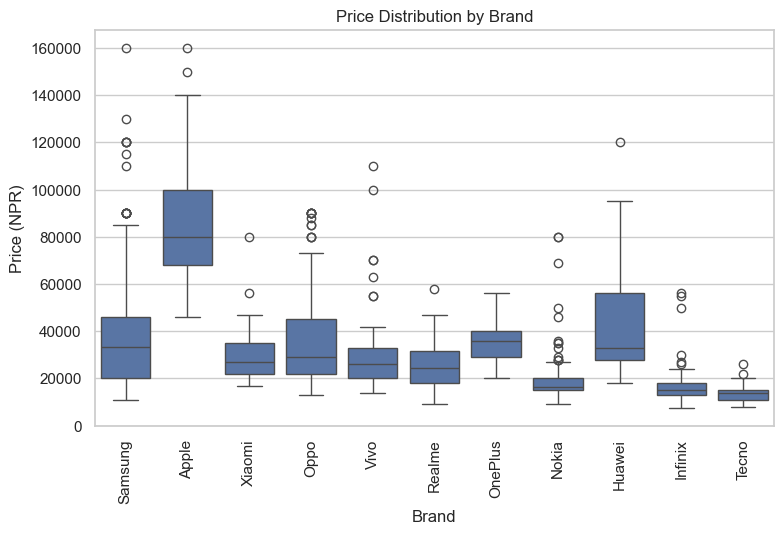

In [25]:
sns.set_theme(style="whitegrid")  
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='brand', y='price_npr')  # numerical = price, categorical = brand

plt.title("Price Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("Price (NPR)")
plt.tight_layout()
plt.tick_params(axis='x', rotation=90)
plt.show()


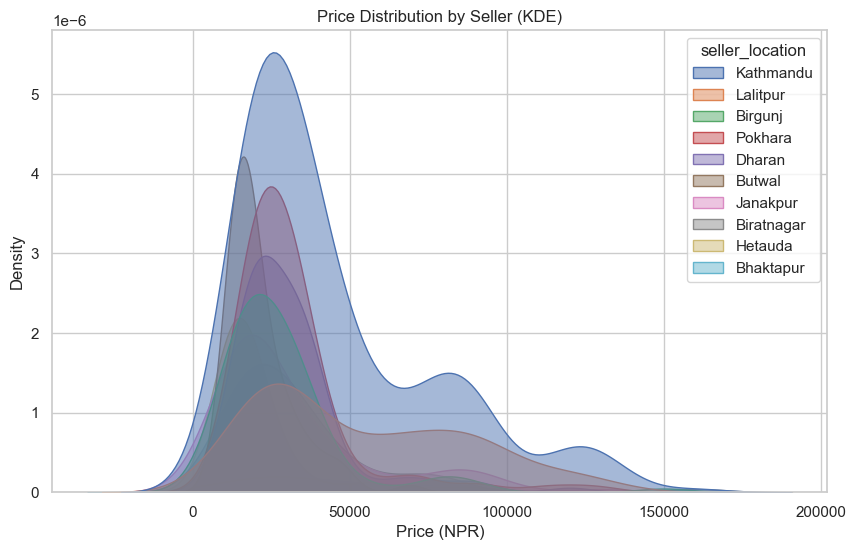

In [26]:
plt.figure(figsize=(10,6))

sns.kdeplot(data=df, x='price_npr', hue='seller_location', fill=True, alpha=0.5)
plt.title("Price Distribution by Seller (KDE)")
plt.xlabel("Price (NPR)")
plt.ylabel("Density")
plt.show()


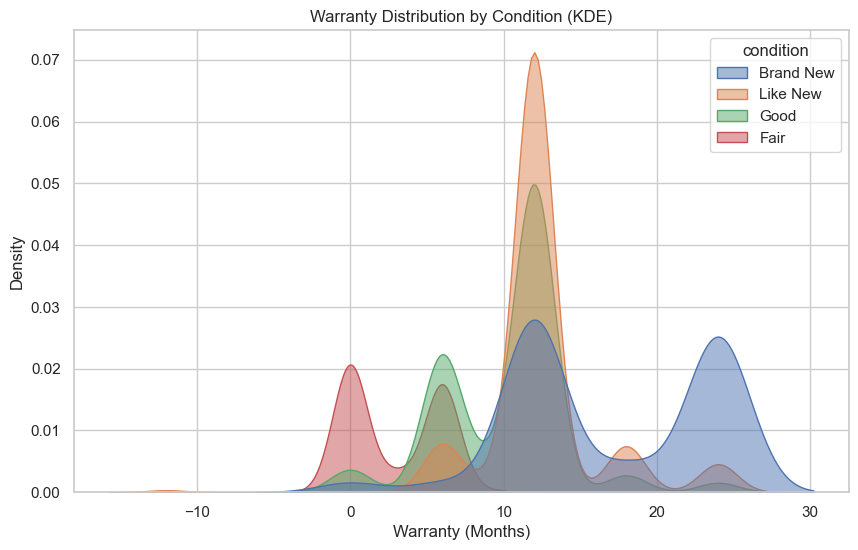

In [27]:
plt.figure(figsize=(10,6))

sns.kdeplot(data=df, x='warranty_months', hue='condition', fill=True, alpha=0.5)
plt.title("Warranty Distribution by Condition (KDE)")
plt.xlabel("Warranty (Months)")
plt.ylabel("Density")
plt.show()


### (Categorical - Categorical) : Feature Analysis

#### Heat Map - Frequency relationships between categorical variables

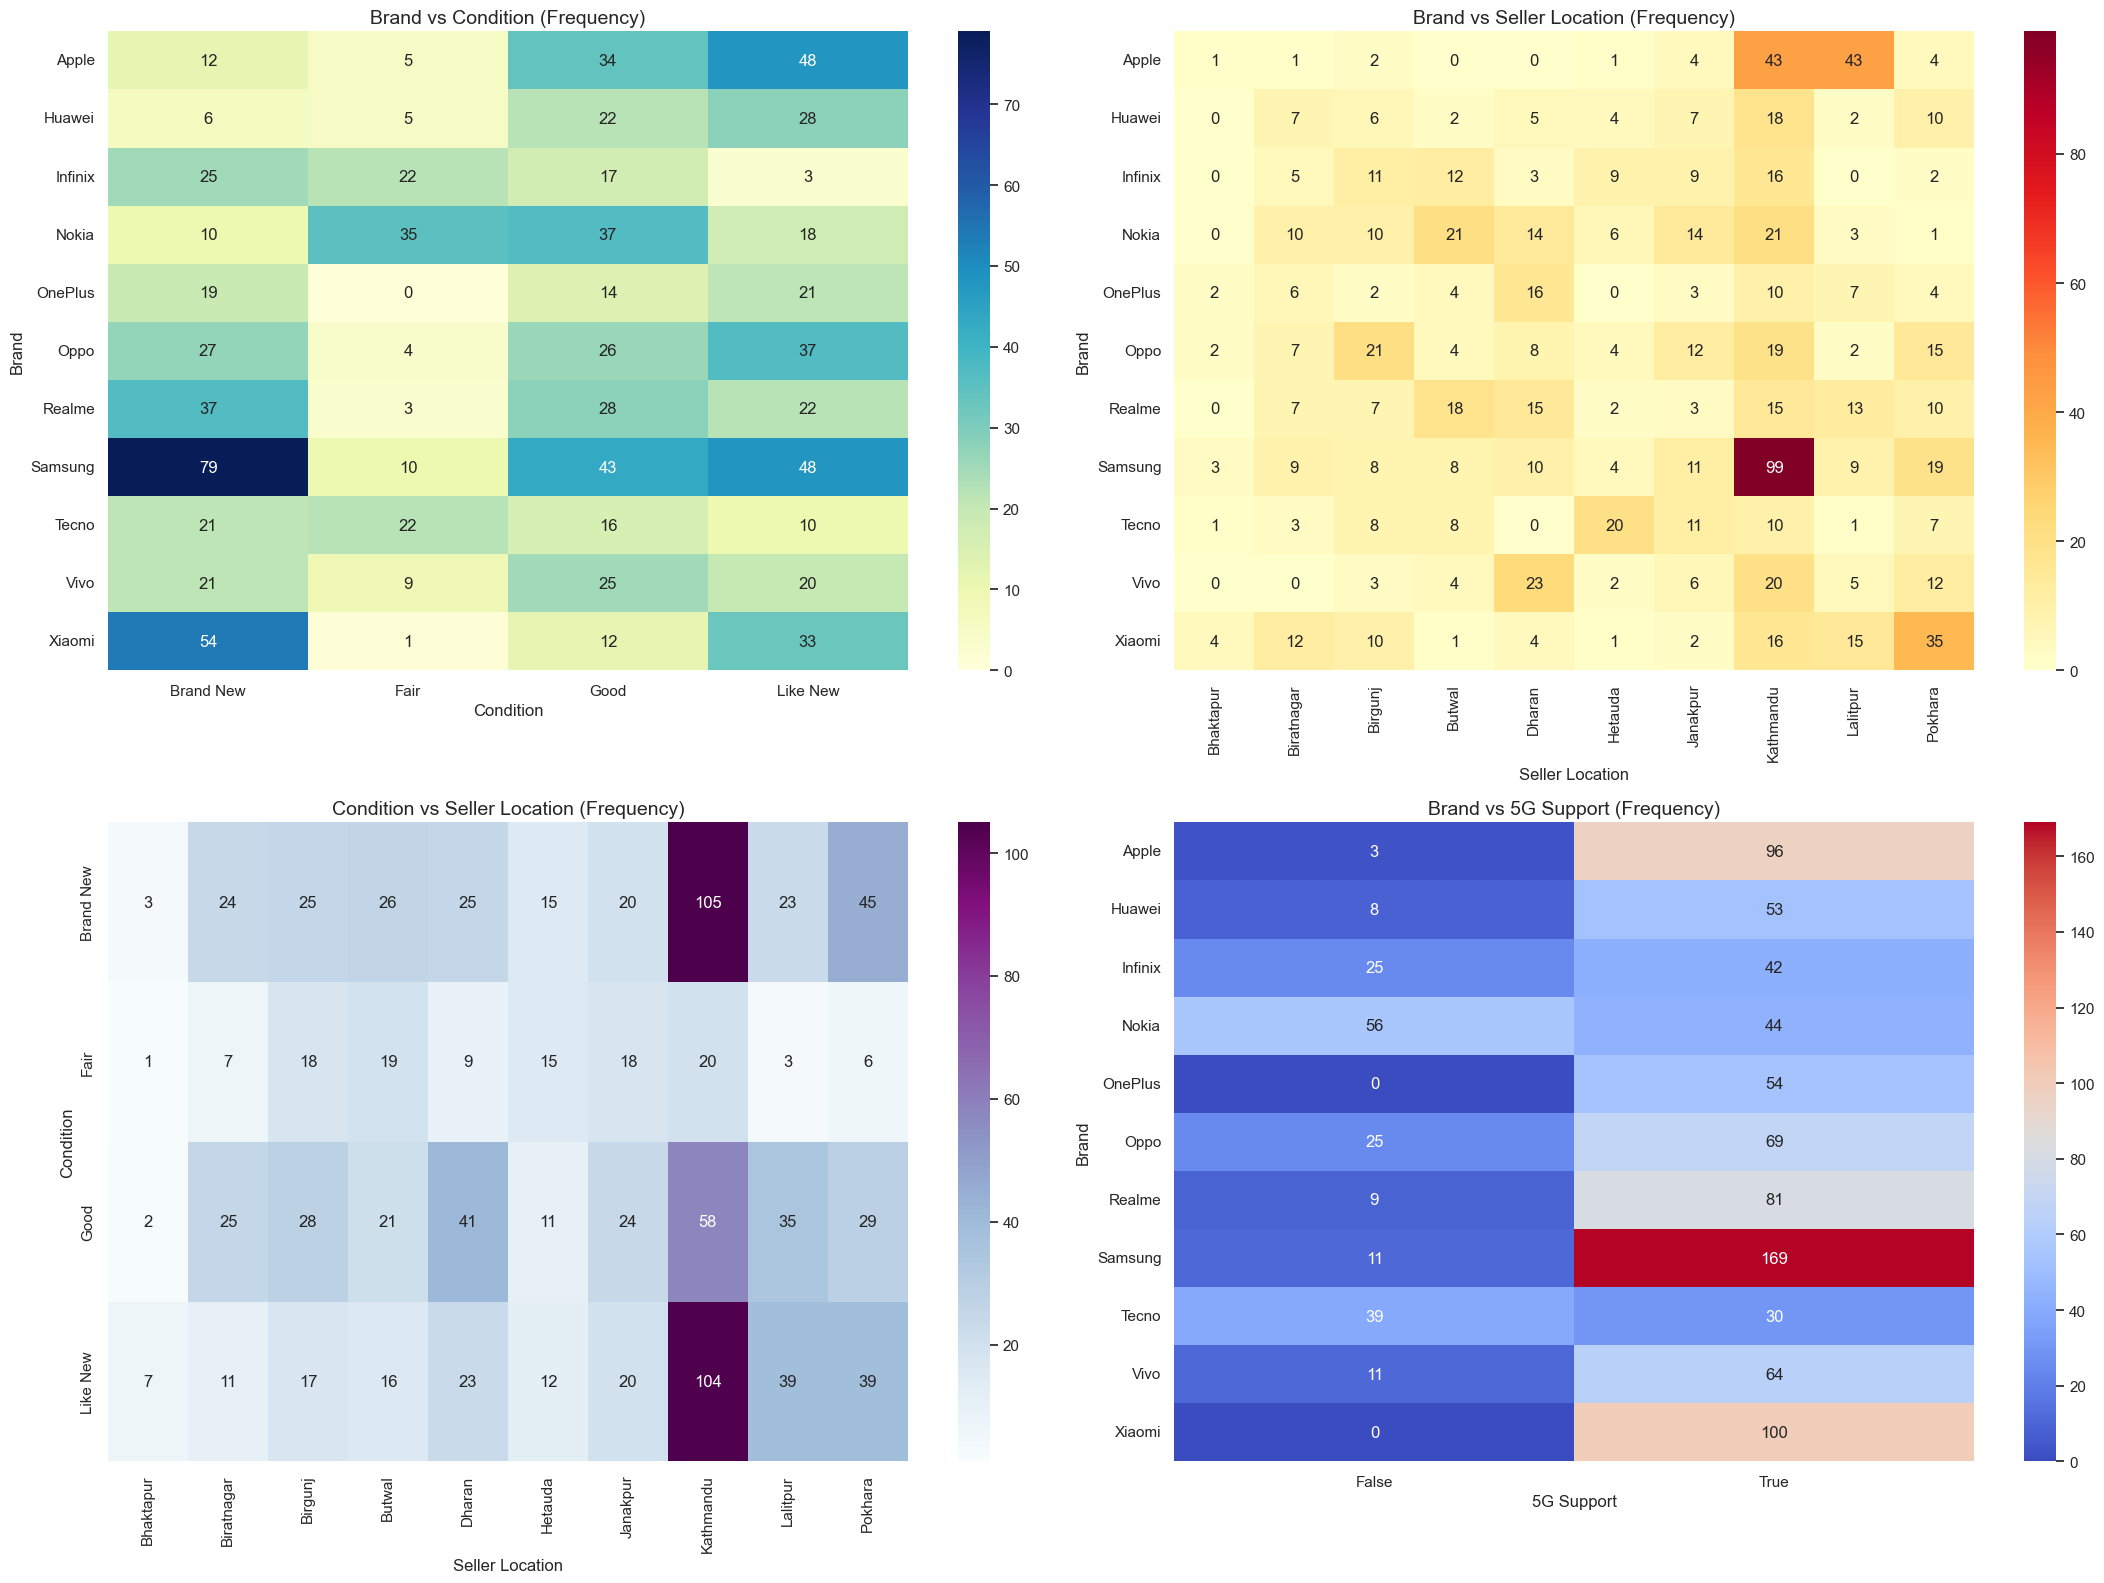

In [31]:
# Select categorical columns for analysis (excluding high-cardinality ones like model_name, processor)
cat_cols = ['brand', 'operating_system', '5g_support', 'fast_charging', 'fingerprint_sensor', 'seller_location', 'condition']

# --- Heat Maps: Frequency relationships between categorical variables ---
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(22, 16))
ax = ax.flatten()

# Brand vs Condition
ct1 = pd.crosstab(df['brand'], df['condition'])
sns.heatmap(ct1, annot=True, fmt='d', cmap='YlGnBu', ax=ax[0])
ax[0].set_title('Brand vs Condition (Frequency)', fontsize=14)
ax[0].set_xlabel('Condition')
ax[0].set_ylabel('Brand')

# Brand vs Seller Location
ct2 = pd.crosstab(df['brand'], df['seller_location'])
sns.heatmap(ct2, annot=True, fmt='d', cmap='YlOrRd', ax=ax[1])
ax[1].set_title('Brand vs Seller Location (Frequency)', fontsize=14)
ax[1].set_xlabel('Seller Location')
ax[1].set_ylabel('Brand')

# Condition vs Seller Location
ct3 = pd.crosstab(df['condition'], df['seller_location'])
sns.heatmap(ct3, annot=True, fmt='d', cmap='BuPu', ax=ax[2])
ax[2].set_title('Condition vs Seller Location (Frequency)', fontsize=14)
ax[2].set_xlabel('Seller Location')
ax[2].set_ylabel('Condition')

# Brand vs 5G Support
ct4 = pd.crosstab(df['brand'], df['5g_support'])
sns.heatmap(ct4, annot=True, fmt='d', cmap='coolwarm', ax=ax[3])
ax[3].set_title('Brand vs 5G Support (Frequency)', fontsize=14)
ax[3].set_xlabel('5G Support')
ax[3].set_ylabel('Brand')

plt.tight_layout()
plt.show()